In [10]:
import pandas as pd
df = pd.read_csv('tuzla_kafici_200.csv')
df.head(56)


,naziv,naselje,cijena_kafe_km,ocjena,terasa,vrsta
0,Cafe Wintera,Stupine,3.5,4.7,Da,Lounge Bar
1,Caffe Cafe,Centar,3.8,4.8,Da,Gradski kafe
2,Caffe Allegro,Stupine,3.2,4.6,Da,Kafeterija
3,Gato,Centar,3.0,4.5,Ne,Kafe bar
4,Verdi,Centar,3.5,4.9,Da,Kafeterija
5,La Linea,Slatina,2.8,4.4,Da,Kvartovski kafe
6,Cafe de Paris,Stari Grad,2.5,4.3,Ne,Kafe bar
7,Sloboda Caffe Bar,Centar,3.5,4.8,Da,Sportski kafe
8,Lobi,Bulevar,3.0,4.6,Da,Moderni kafe
9,Osmica,Ilinčica,4.0,4.9,Da,Vidikovac/Restoran


In [11]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   naziv           200 non-null    str    
 1   naselje         200 non-null    str    
 2   cijena_kafe_km  200 non-null    float64
 3   ocjena          200 non-null    float64
 4   terasa          200 non-null    str    
 5   vrsta           200 non-null    str    
dtypes: float64(2), str(4)
memory usage: 9.5 KB


naziv             0
naselje           0
cijena_kafe_km    0
ocjena            0
terasa            0
vrsta             0
dtype: int64

In [12]:
broj_redova, broj_kolona = df.shape
print(f"Dataset sadrži {broj_redova} redova i {broj_kolona} kolona.")
df.describe()

Dataset sadrži 200 redova i 6 kolona.


,cijena_kafe_km,ocjena
count,200.000000,200.00000
mean,3.102000,4.41900
std,0.448443,0.26982
min,2.200000,3.90000
25%,2.800000,4.20000
50%,3.100000,4.40000
75%,3.500000,4.70000
max,4.000000,4.90000


In [14]:
df.describe().round(1)


,cijena_kafe_km,ocjena
count,200.0,200.0
mean,3.1,4.4
std,0.4,0.3
min,2.2,3.9
25%,2.8,4.2
50%,3.1,4.4
75%,3.5,4.7
max,4.0,4.9


In [11]:
# Kafići koji imaju terasu i ocjenu veću od 4.7
top_terasa = df[(df['terasa'] == 'Da') & (df['ocjena'] > 4.7)]
top_terasa.head()

,naziv,naselje,cijena_kafe_km,ocjena,terasa,vrsta
1,Caffe Cafe,Centar,3.8,4.8,Da,Gradski kafe
4,Verdi,Centar,3.5,4.9,Da,Kafeterija
7,Sloboda Caffe Bar,Centar,3.5,4.8,Da,Sportski kafe
9,Osmica,Ilinčica,4.0,4.9,Da,Vidikovac/Restoran
14,Kafeterija Tuzla,Centar,3.8,4.8,Da,Kafeterija


In [12]:
# Prosječna cijena kafe i ocjena po naseljima 
analiza_naselja = df.groupby('naselje')[['cijena_kafe_km', 'ocjena']].mean().reset_index()

analiza_naselja['cijena_kafe_km'] = analiza_naselja['cijena_kafe_km'].round(2)
analiza_naselja['ocjena'] = analiza_naselja['ocjena'].round(2)

analiza_naselja = analiza_naselja.sort_values(by='cijena_kafe_km', ascending=False)
analiza_naselja

,naselje,cijena_kafe_km,ocjena
2,Bulevar,3.74,4.81
3,Centar,3.56,4.70
11,Stupine,3.27,4.48
10,Stari Grad,3.21,4.54
4,Ilinčica,3.19,4.51
12,Trnovac,2.95,4.35
8,Slatina,2.84,4.27
7,Sjenjak,2.79,4.25
1,Brčanska Malta,2.78,4.18
5,Kula,2.63,4.13


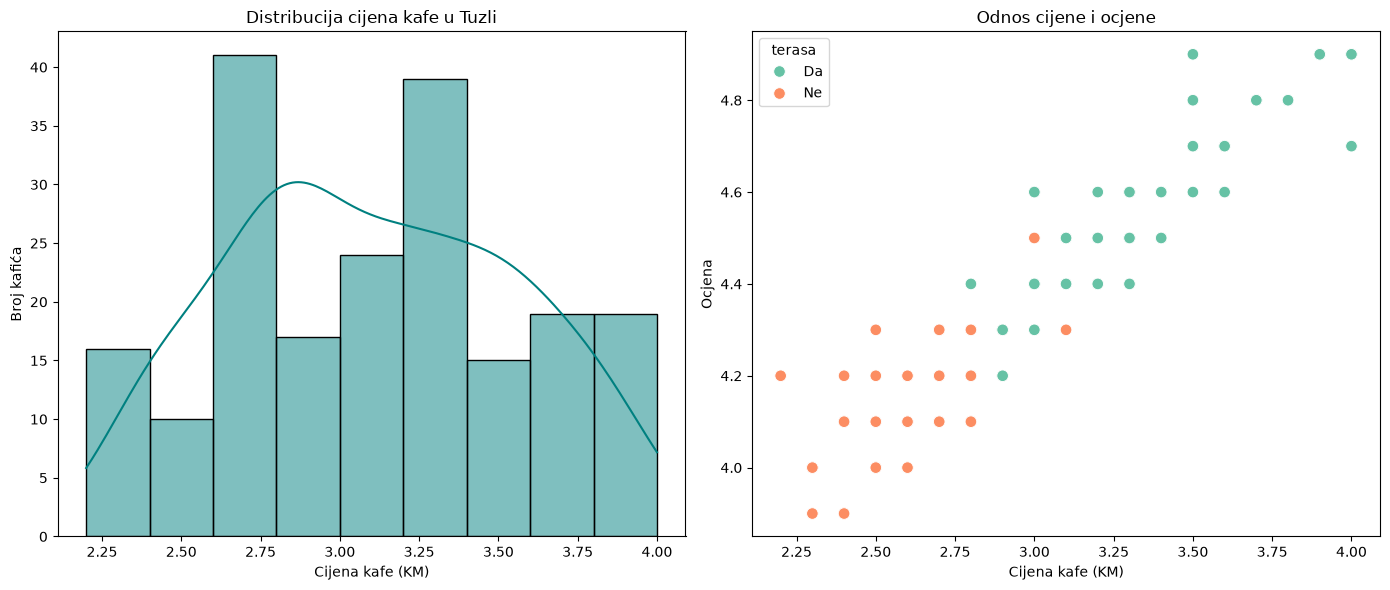

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Graf 1: Distribucija cijena kafe
plt.subplot(1, 2, 1)
sns.histplot(df['cijena_kafe_km'], kde=True, color='teal')
plt.title('Distribucija cijena kafe u Tuzli')
plt.xlabel('Cijena kafe (KM)')
plt.ylabel('Broj kafića')

# Graf 2: Odnos cijene i ocjene
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='cijena_kafe_km', y='ocjena', hue='terasa', palette='Set2', s=70)
plt.title('Odnos cijene i ocjene')
plt.xlabel('Cijena kafe (KM)')
plt.ylabel('Ocjena')

plt.tight_layout()
plt.show()

Na osnovu provedene eksploratorne analize podataka(EDA) za 200 kafića u Tuzli, možemo zaključiti da se cijene kafe najčešće kreću u rasponu od 2.75 do 3.50 KM, uz stabilan kvalitet usluge budući da većina objekata bilježi visoke ocjene iznad 4.0. Također, vizuelna analiza otkriva jasnu povezanost između postojanja terase, više cijene i bolje ocjene gostiju, s obzirom na to da lokali s terasom dominantno zauzimaju viši cjenovni rang. Ugostiteljska ponuda nudi dobar balans pristupačnosti i kvaliteta, pri čemu dodatni sadržaji poput terase značajno utiču na pozicioniranje i ocjenu samog objekta.